<a href="https://colab.research.google.com/github/clementeyquem/Linear_Regression/blob/main/Linear_Regression_Module_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [74]:
# =============================================================================
# 1. IMPORT DES DONNÉES
# =============================================================================

spx = yf.download('^GSPC', start='2000-01-01', end='2024-12-31', auto_adjust=True)
vix = yf.download('^VIX', start='2000-01-01', end='2024-12-31', auto_adjust=True)

spx_close = spx['Close'].squeeze()
vix_close = vix['Close'].squeeze()

log_ret = np.log(spx_close / spx_close.shift(1))
realized_vol = log_ret.rolling(21).std() * np.sqrt(252) * 100
df = pd.DataFrame({'VIX': vix_close, 'RealizedVol': realized_vol}).dropna()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [75]:
# =============================================================================
# 2. FEATURE ENGINEERING — LAGS
# =============================================================================

df['VIX_lag1'] = df['VIX'].shift(1) # VIX d'hier (1 jour)
df['VIX_lag5'] = df['VIX'].shift(5) # VIX de la semaine passée
df['VIX_lag21'] = df['VIX'].shift(21) # VIX du mois passé
df['DVIX_lag1'] = df['VIX'].diff(1).shift(1) # Variation du VIX d'hier

df = df.dropna() # Supprime les NaN introduits par les lags
print(f'Après dropna : {len(df)} observations')
print(df[['VIX', 'VIX_lag1', 'VIX_lag5', 'DVIX_lag1']].head(3).round(2))


Après dropna : 6246 observations
              VIX  VIX_lag1  VIX_lag5  DVIX_lag1
Date                                            
2000-03-03  19.21     21.06     25.20      -0.58
2000-03-06  21.50     19.21     24.68      -1.85
2000-03-07  24.31     21.50     23.37       2.29


In [76]:
# =============================================================================
# 3. TRAIN / TEST SPLIT — CHRONOLOGIQUE
# =============================================================================

split_idx = int(len(df) * 0.80)
split_date = df.index[split_idx]

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

features = ['VIX_lag1', 'VIX_lag5', 'VIX_lag21', 'DVIX_lag1']
target = 'RealizedVol'

X_train, y_train = train[features].values, train[target].values
X_test, y_test = test[features].values, test[target].values

print(f'\nSplit date : {split_date.date()}')
print(f'Train : {len(train)} obs | Test : {len(test)} obs')




Split date : 2020-01-13
Train : 4996 obs | Test : 1250 obs


In [77]:
# =============================================================================
# 4. MODÈLE BASELINE — M1 (VIX lag 1 uniquement)
# =============================================================================

m1 = LinearRegression()
m1.fit(train[['VIX_lag1']].values, y_train)

y_pred_m1_train = m1.predict(train[['VIX_lag1']].values)
y_pred_m1_test = m1.predict(test[['VIX_lag1']].values)

In [78]:
# =============================================================================
# 5. MODÈLE M2 — RÉGRESSION MULTIPLE AVEC LAGS
# =============================================================================

m2 = LinearRegression()
m2.fit(X_train, y_train)

y_pred_m2_train = m2.predict(X_train)
y_pred_m2_test = m2.predict(X_test)

# Affichage des coefficients

print('\n=== Coefficients M2 ===')
print(f' Intercept : {m2.intercept_:.4f}')
for feat, coef in zip(features, m2.coef_):
  print(f' {feat:12s} : {coef:.4f}')



=== Coefficients M2 ===
 Intercept : -5.6183
 VIX_lag1     : 0.5358
 VIX_lag5     : 0.6094
 VIX_lag21    : -0.0318
 DVIX_lag1    : -0.2229


In [79]:
# =============================================================================
# 6. MÉTRIQUES
# =============================================================================

def compute_metrics(y_true, y_pred, label):
  r2 = r2_score(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae = mean_absolute_error(y_true, y_pred)
  print(f'{label:25s} R²={r2:.4f} RMSE={rmse:.3f} MAE={mae:.3f}')
  return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

print('\n=== Métriques ===')
m1_train_m = compute_metrics(y_train, y_pred_m1_train, 'M1 – Train')
m1_test_m = compute_metrics(y_test, y_pred_m1_test, 'M1 – Test (out-of-sample)')
m2_train_m = compute_metrics(y_train, y_pred_m2_train, 'M2 – Train')
m2_test_m = compute_metrics(y_test, y_pred_m2_test, 'M2 – Test (out-of-sample)')


=== Métriques ===
M1 – Train                R²=0.8137 RMSE=4.387 MAE=3.103
M1 – Test (out-of-sample) R²=0.7004 RMSE=6.707 MAE=4.100
M2 – Train                R²=0.8478 RMSE=3.965 MAE=2.828
M2 – Test (out-of-sample) R²=0.7625 RMSE=5.971 MAE=3.767


In [80]:
# =============================================================================
# 7. IMPORTANCE DES FEATURES (coefficients standardisés)
# =============================================================================

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test) # transform seulement !

m2_sc = LinearRegression().fit(X_train_sc, y_train)

print('\n=== Importance des features (coef. standardisés) ===')
for feat, coef in zip(features, m2_sc.coef_):
  print(f' {feat:12s} : {coef:.3f}')



=== Importance des features (coef. standardisés) ===
 VIX_lag1     : 4.551
 VIX_lag5     : 5.175
 VIX_lag21    : -0.270
 DVIX_lag1    : -0.372


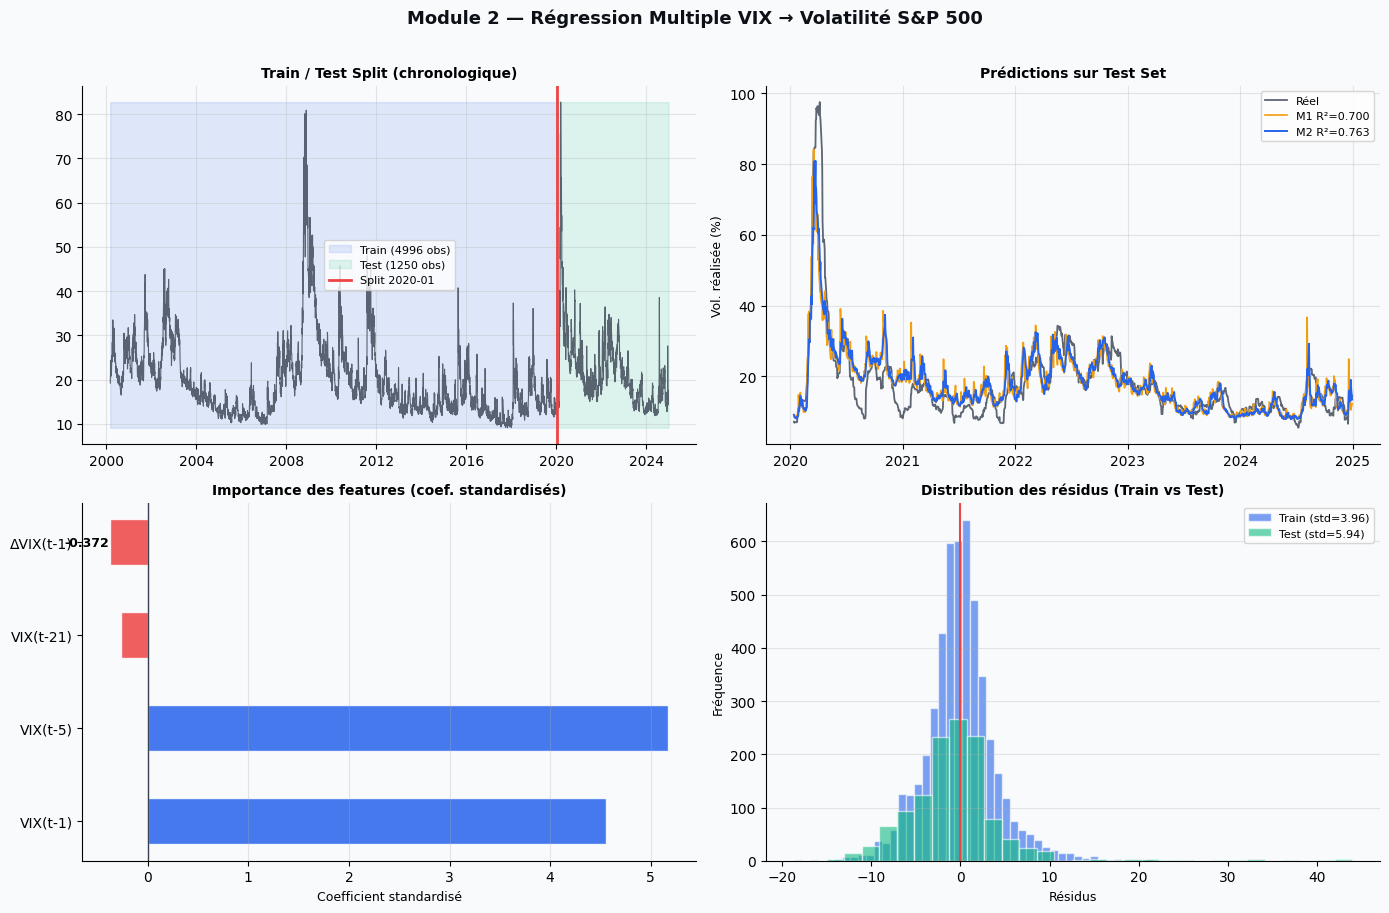


Graphique sauvegardé : module2_results.png


In [81]:
# =============================================================================
# 8. VISUALISATIONS
# =============================================================================

PLT_BG = '#F8FAFC'
fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor=PLT_BG)
fig.suptitle('Module 2 — Régression Multiple VIX → Volatilité S&P 500',
fontsize=13, fontweight='bold', color='#0D1117', y=1.01)

# ── Fig 1 : Train/Test split ──────────────────

ax = axes[0, 0]
ax.fill_between(train.index, df['VIX'].min(), df['VIX'].max(),
alpha=0.12, color='#2563EB', label=f'Train ({len(train)} obs)')
ax.fill_between(test.index, df['VIX'].min(), df['VIX'].max(),
alpha=0.12, color='#10B981', label=f'Test ({len(test)} obs)')
ax.plot(df.index, df['VIX'], color='#374151', lw=0.8, alpha=0.8)
ax.axvline(split_date, color='#EF4444', lw=2, linestyle='-',
label=f'Split {split_date.strftime('%Y-%m')}')
ax.set_title('Train / Test Split (chronologique)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='-')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Fig 2 : Prédictions sur le test set ───────

ax = axes[0, 1]
ax.plot(test.index, y_test, color='#374151', lw=1.3, alpha=0.8, label='Réel')
ax.plot(test.index, y_pred_m1_test, color='#F59E0B', lw=1.2, linestyle='-',
label=f'M1 R²={m1_test_m['R2']:.3f}')
ax.plot(test.index, y_pred_m2_test, color='#2563EB', lw=1.4,
label=f'M2 R²={m2_test_m['R2']:.3f}')
ax.set_title('Prédictions sur Test Set', fontsize=10, fontweight='bold')
ax.set_ylabel('Vol. réalisée (%)', fontsize=9)
ax.legend(fontsize=8)
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='-')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Fig 3 : Importance des features ───────────

ax = axes[1, 0]
feat_labels = ['VIX(t-1)', 'VIX(t-5)', 'VIX(t-21)', 'ΔVIX(t-1)']
bar_colors = ['#2563EB' if c > 0 else '#EF4444' for c in m2_sc.coef_]
bars = ax.barh(feat_labels, m2_sc.coef_, color=bar_colors, alpha=0.85,
edgecolor='white', height=0.5)
ax.axvline(0, color='#374151', lw=1)
for bar, val in zip(bars, m2_sc.coef_):
    offset = 0.01 \
    if val >= 0 \
    else -0.01
    ha = 'left' \
    if val >= 0 \
    else 'right'
ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')
ax.set_title('Importance des features (coef. standardisés)', fontsize=10, fontweight='bold')
ax.set_xlabel('Coefficient standardisé', fontsize=9)
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='-', axis='x')
ax.spines[['top', 'right']].set_visible(False)

# ── Fig 4 : Résidus Train vs Test ─────────────

ax = axes[1, 1]
res_train = y_train - y_pred_m2_train
res_test = y_test - y_pred_m2_test
ax.hist(res_train, bins=50, color='#2563EB', alpha=0.6,
edgecolor='white', lw=0.3, label=f'Train (std={res_train.std():.2f})')
ax.hist(res_test, bins=30, color='#10B981', alpha=0.6,
edgecolor='white', lw=0.3, label=f'Test (std={res_test.std():.2f})')
ax.axvline(0, color='#EF4444', lw=1.5, linestyle='-')
ax.set_title('Distribution des résidus (Train vs Test)', fontsize=10, fontweight='bold')
ax.set_xlabel('Résidus', fontsize=9)
ax.set_ylabel('Fréquence', fontsize=9)
ax.legend(fontsize=8)
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='-', axis='y')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('module2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGraphique sauvegardé : module2_results.png')